## *Student Performance Indicator*


*Life cycle of ML Project* 

* Understanding the problrm statement 
* Data Collection 
* Data checks to perform 
* Exploratory Data Analysis 
* Data pre-processing 
* Model Training 
* choose best Model 

# 1) Problem Statement 
* This project understands the student's performance (test score) is affected by other variables such as gender,Ethnicity ,parental level of education,Lunch and test preparation course 

# 2) Data Collection 
* Data Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
* The Data consist of 8 columns and 1000 rows.

# 2.1) Import Data and rquired pacakages


*Importing pandas ,numpy,matplotlib,Seaborn and warning Library.*

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

*Import CSV data as pandas DataFrame*

In [2]:
df = pd.read_csv('data/stud.csv')

*Show Top 5 Rows*

In [3]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


*Shape of Dataset*

In [4]:
df.shape

(1000, 8)

# 2.2) Dataset Information

* gender : sex of students -> (Male/female)
* race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
* parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
* lunch : having lunch before test (standard or free/reduced)
* test preparation course : complete or not complete before test
* math score
* reading score
* writing score

# 3. Data checks to perform 
* Check Missing values
* Check Duplicates
* Check data type
* Check the number of unique values of each column
* Check statistics of data set
* Check various categories present in the different categorical column

# 3.1) Checking Missing Values

In [5]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

*There are no null values in dataset* 

# 3.2) Check Duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

*There are no duplicates present in dataset*

# 3.3) Check data Type

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


# 3.4) Checking uniques values in each column 

In [8]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

# 3.5) Check Statistics of dataset 

In [9]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


*Insight*
* From above description of numerical data , all mean are very close to each other (66.08 to 68.05)
* All standard deviation are also close - between 14.60 to 15.19
* While there is minimum score for maths is 0 , reading is 17 , writing is 10

# 3.6) Exploring Data

In [10]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
for i in df.columns:
    if df[i].dtype == 'str':
     print(f'Categories in {i} variable are : {df[i].unique()} \n',end=" ")
     

Categories in gender variable are : <StringArray>
['female', 'male']
Length: 2, dtype: str 
 Categories in race_ethnicity variable are : <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str 
 Categories in parental_level_of_education variable are : <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str 
 Categories in lunch variable are : <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str 
 Categories in test_preparation_course variable are : <StringArray>
['none', 'completed']
Length: 2, dtype: str 
 

In [12]:
#define categorical and numerical columns 

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

# print Columns 
print(f'We have {len(numeric_features)} numerical features : {numeric_features}\n')
print(f'We have {len(categorical_features)} categorical features : {categorical_features}\n')

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']



In [13]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


*Adding column for Total Score And Average Score*

In [14]:
df['Total_score'] = df['math_score']+df['reading_score']+df['writing_score']
df['Average_score'] = df['Total_score']/3

In [15]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
reading_full = df[df['reading_score']==100]['Average_score'].count()
writing_full = df[df['writing_score']==100]['Average_score'].count()
math_full = df[df['math_score']==100]['Average_score'].count()

print(f'Number of students who got full marks in reading : {reading_full}')
print(f'Number of students who got full marks in writing : {writing_full}')
print(f'Number of students who got full marks in math : {math_full}')

Number of students who got full marks in reading : 17
Number of students who got full marks in writing : 14
Number of students who got full marks in math : 7


In [17]:
reading_less_20 = df[df['reading_score'] <= 20]['Average_score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['Average_score'].count()
math_less_20 = df[df['math_score'] <= 20]['Average_score'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


*Insights*
* From above values we get that students perform worst in maths 
* students perform best in reading 

# 4) Exploring Data (visualization)
*4.1) Visualize average score distribution to make some conclusion* 
* Histogram 
* Kernal Distribution Function(KDF) 


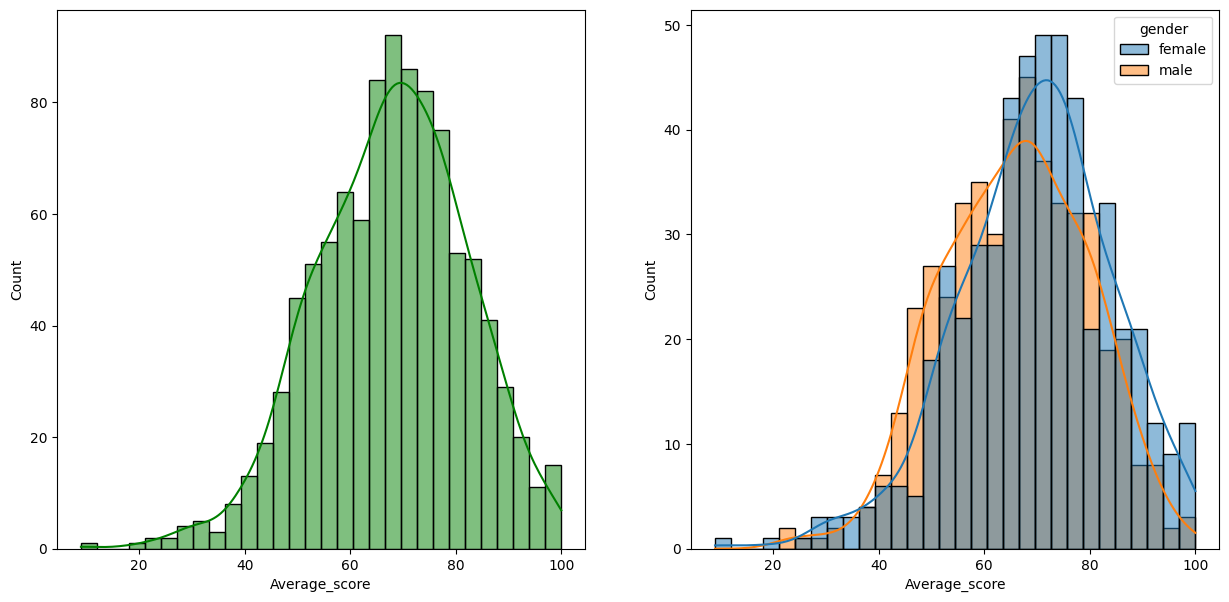

In [18]:
fig,ax = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data = df ,x='Average_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average_score',bins=30,kde=True,hue='gender')
plt.show()

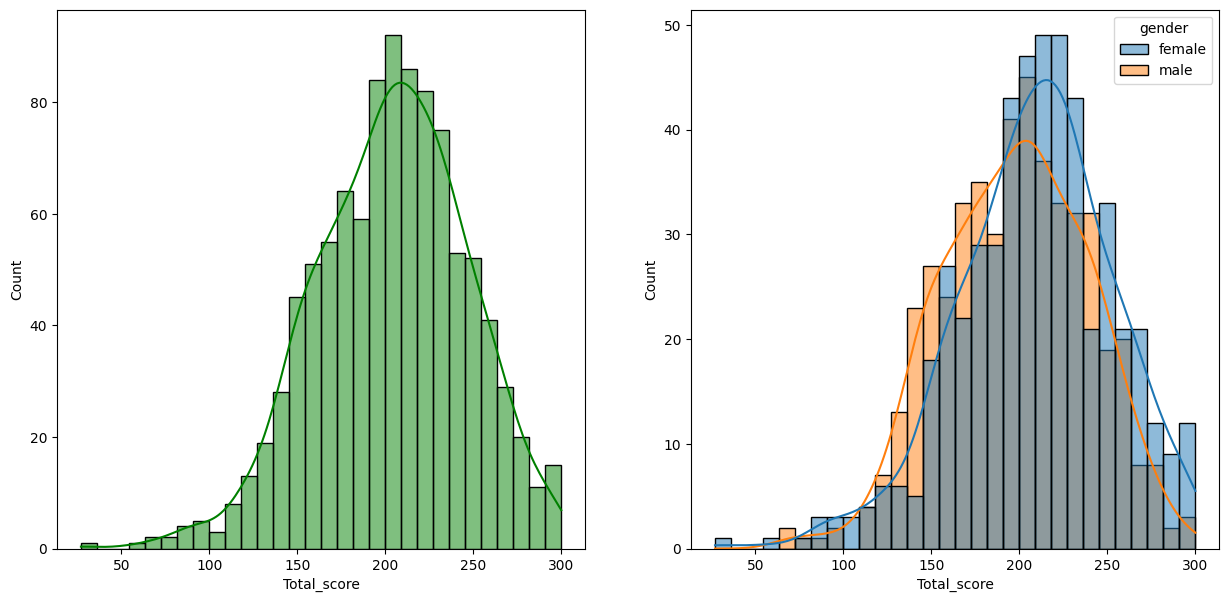

In [19]:
fig,ax = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data = df ,x='Total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Total_score',bins=30,kde=True,hue='gender')
plt.show()

*Insight*
* Female Students are performing better

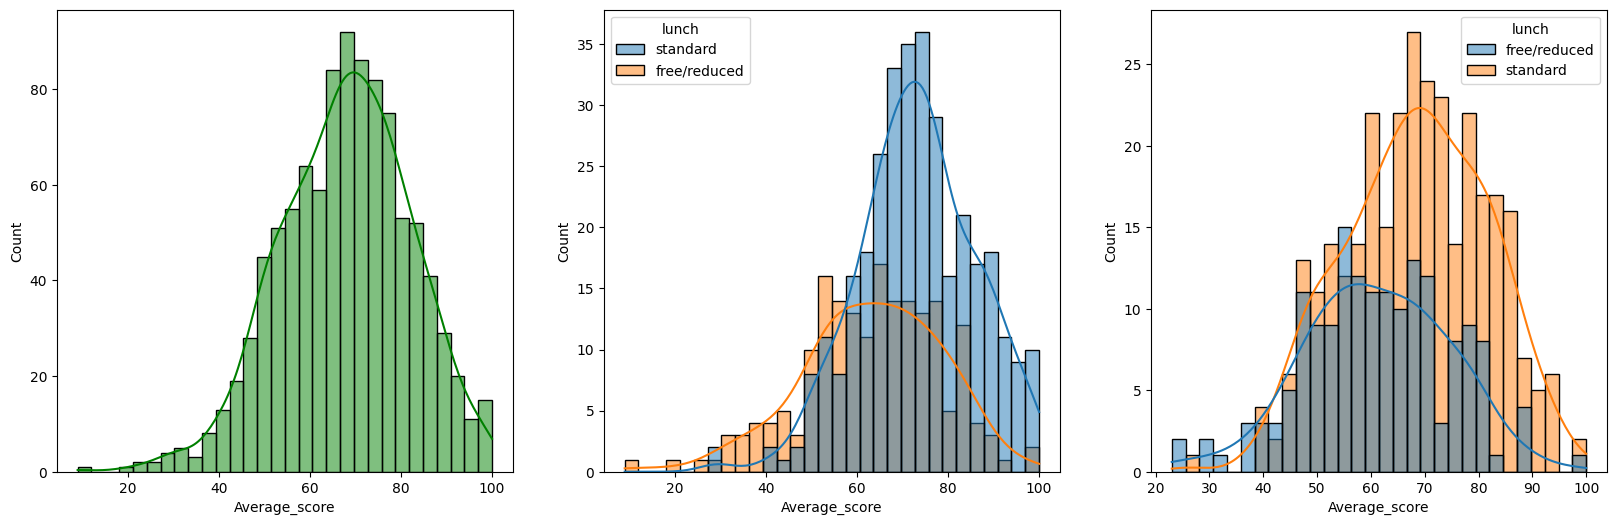

In [20]:
fig,ax=plt.subplots(1,3,figsize=(20,6))
plt.subplot(131)
sns.histplot(data=df,x='Average_score',bins=30,kde=True,color='g')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='Average_score',bins=30,kde=True,hue='lunch')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='Average_score',bins=30,kde=True,hue='lunch')
plt.show()

*Insight*
* Students who are having  Standard lunch are performing better.
* Standard lunch helps in performing well in exams either it is male or female

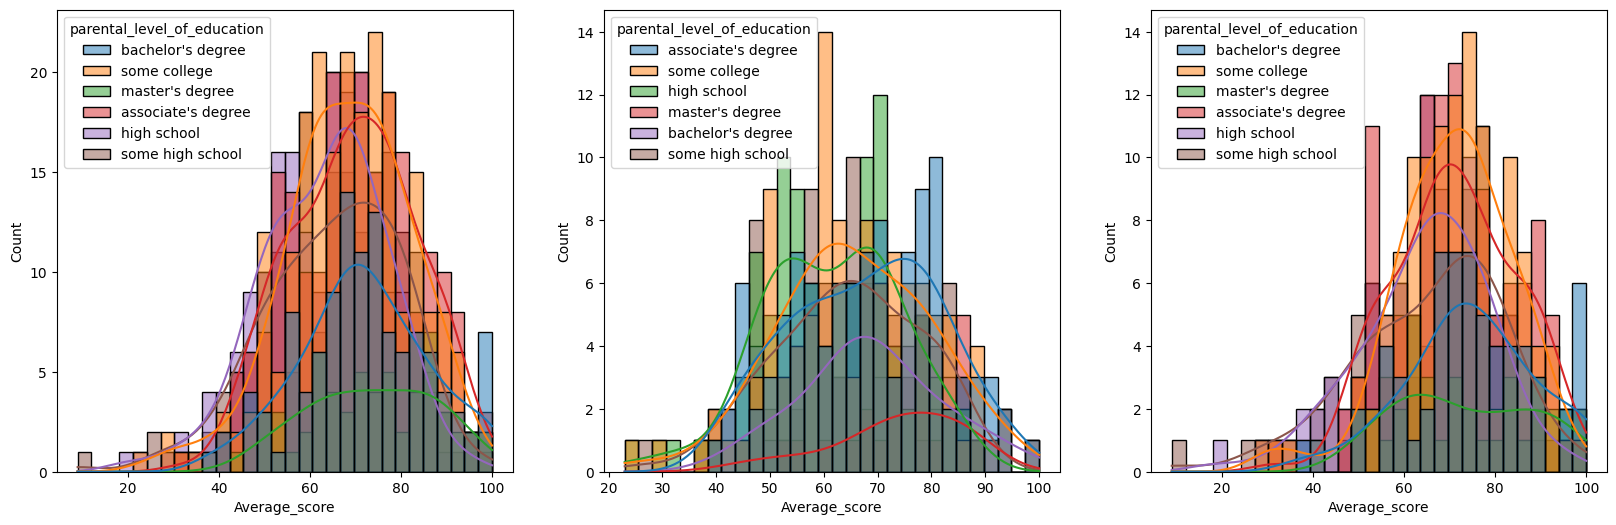

In [21]:
fix,ax=plt.subplots(1,3,figsize=(20,6))
plt.subplot(131)
sns.histplot(data=df,x='Average_score',bins=30,kde=True,hue='parental_level_of_education')
plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='Average_score',bins=30,kde=True,hue='parental_level_of_education')
plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='Average_score',bins=30,kde=True,hue='parental_level_of_education')
plt.show()

*Insights*
* In general parent's education don't help student perform well in exam.
* 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
* 3rd plot we can see there is no effect of parent's education on female students.

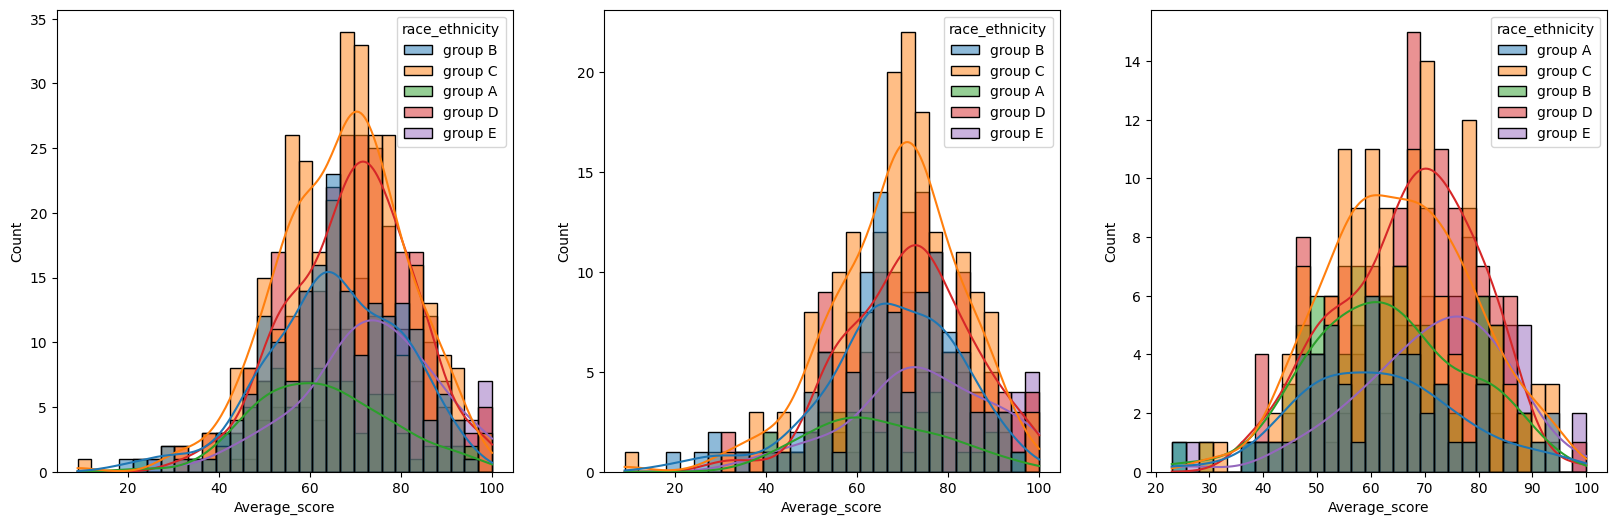

In [22]:
fig,ax=plt.subplots(1,3,figsize=(20,6))
plt.subplot(131)
sns.histplot(data=df,x='Average_score',bins=30,kde=True,hue='race_ethnicity')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='Average_score',bins=30,kde=True,hue='race_ethnicity')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='Average_score',bins=30,kde=True,hue='race_ethnicity')
plt.show()


*insights*
* Students of group A and group B tends to perform poorly in exam.
* Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

*4.2) Maximum score of students in all 3 subjects*


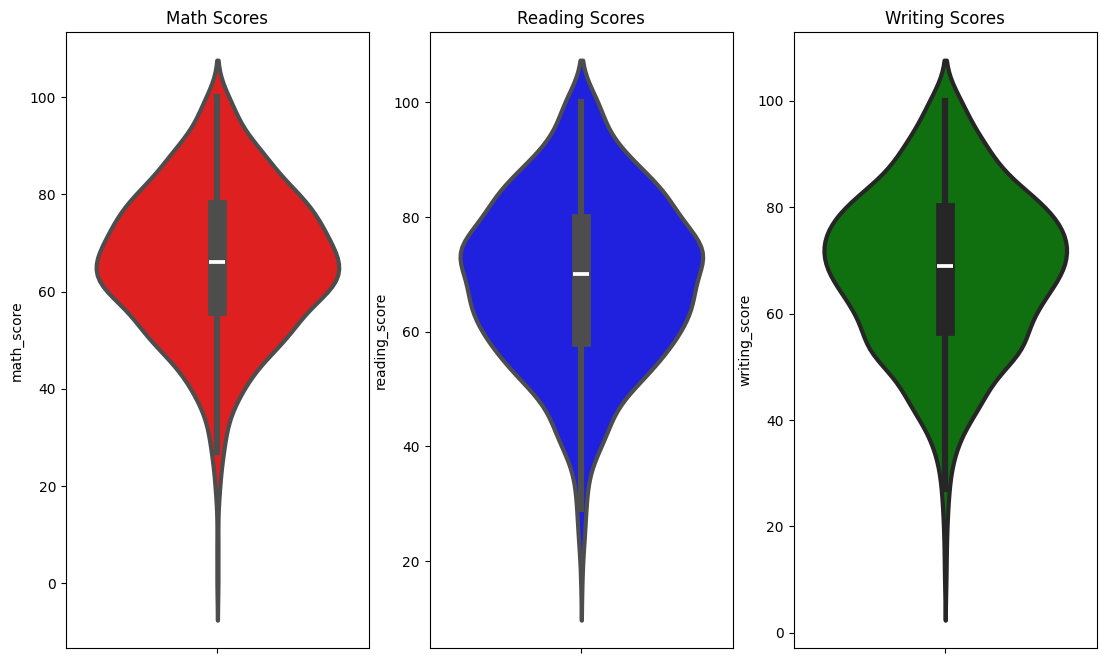

In [23]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title("Math Scores")
sns.violinplot(data=df,y='math_score',color='red',linewidth=3)
plt.subplot(1,4,2)
plt.title("Reading Scores")
sns.violinplot(data=df,y='reading_score',color='blue',linewidth=3)
plt.subplot(1,4,3)
plt.title("Writing Scores")
sns.violinplot(data=df,y='writing_score',color='green',linewidth=3)
plt.show()

*Insight*
* From above 3 graph we can conclude that students score 50-80 in maths ,whereas the writing and reading score is 60-80

*4.3) Multivaritive Analysis using pieplot*

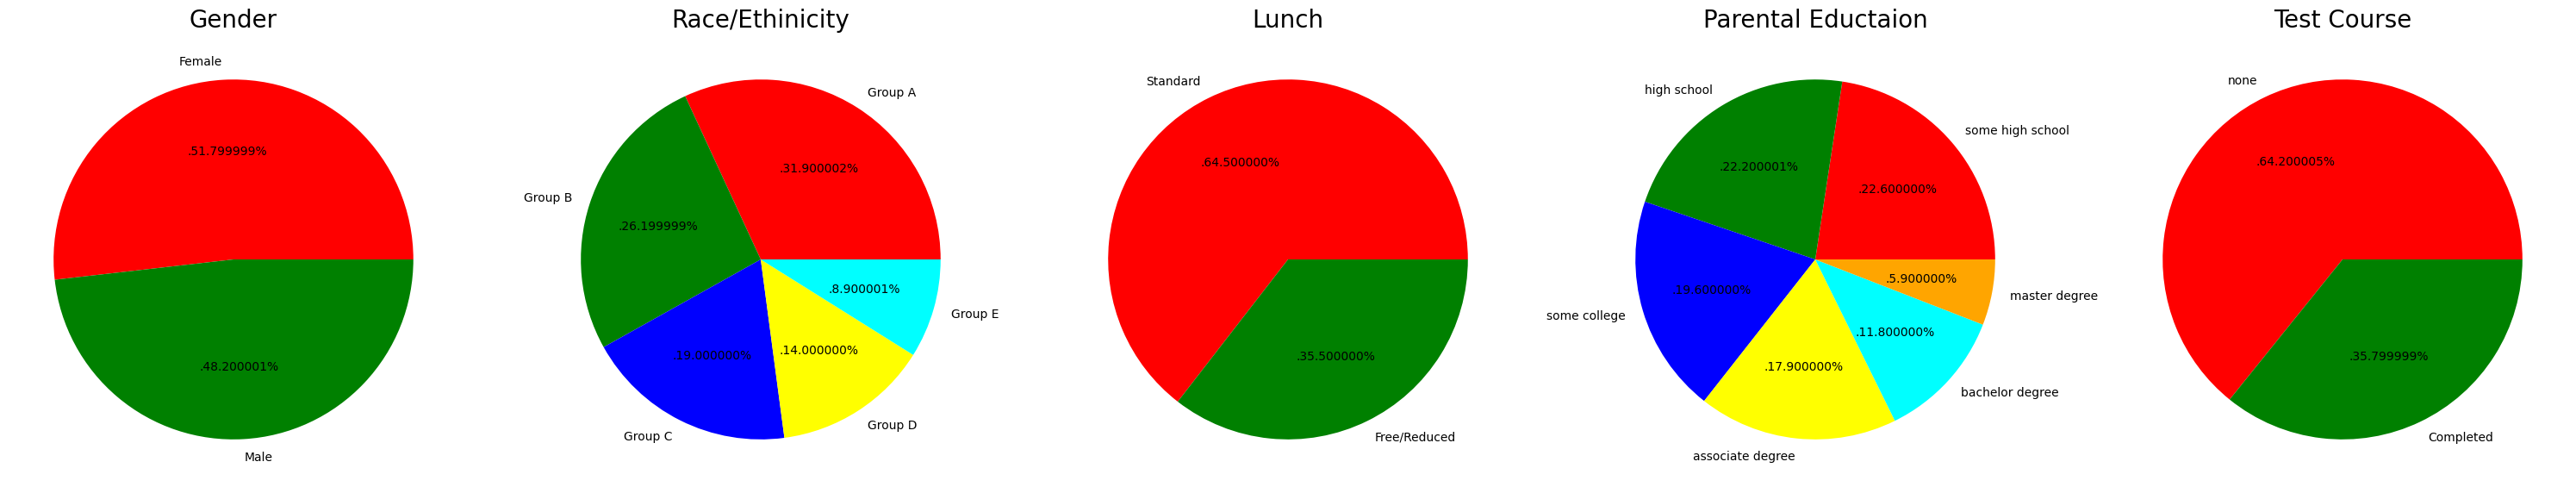

In [24]:
plt.rcParams['figure.figsize']=(30,12)

plt.subplot(1,5,1)
size =df['gender'].value_counts()
labels='Female','Male'
color =['red','green']
plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('Gender',fontsize=20)
plt.axis('off')

plt.subplot(1,5,2)
size = df['race_ethnicity'].value_counts()
labels='Group A','Group B','Group C','Group D','Group E'
color = ['red','green','blue','yellow','cyan','orange']
plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('Race/Ethinicity',fontsize=20)
plt.axis('off')

plt.subplot(1,5,3)
size=df['lunch'].value_counts()
labels='Standard','Free/Reduced'
color = ['red','green']
plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('Lunch',fontsize=20)
plt.axis('off')

plt.subplot(1,5,4)
size=df["parental_level_of_education"].value_counts()
labels = 'some high school','high school','some college','associate degree','bachelor degree','master degree'
color = ['red','green','blue','yellow','cyan','orange']
plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('Parental Eductaion',fontsize=20)
plt.axis('off')

plt.subplot(1,5,5)
size=df['test_preparation_course'].value_counts()
labels = 'none','Completed'
color = ['red','green']
plt.pie(size,colors=color,labels=labels,autopct='.%2f%%')
plt.title('Test Course',fontsize=20)
plt.axis('off')

plt.tight_layout()
plt.grid()
plt.show()

*Insights*
* Number of Male and Female are almost equal 
* Number of students are greatest in Group B
* Number of students having standard Lunch are greater
* Number of students who have not enrolled in any test preparation course is greater
* Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

*Feature Wise Visualization*
# Gender Column
*  How is distribution of gender 
* Does Gender has any impact on student's performance  

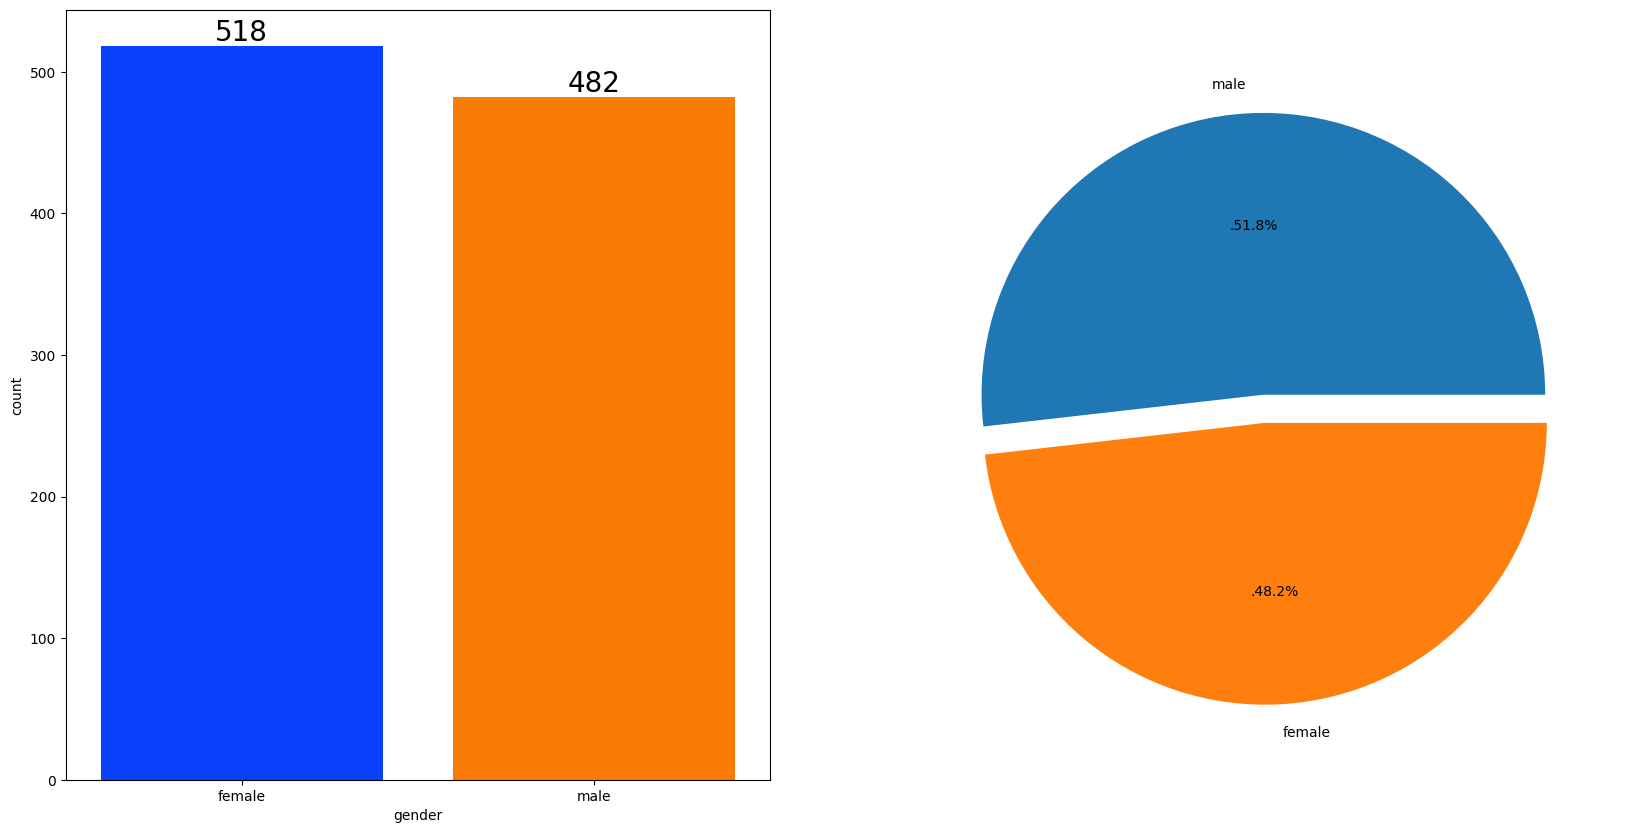

In [25]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df,x=df['gender'],palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
plt.pie(x=df['gender'].value_counts(),labels=["male","female"],explode=[0,0.1],autopct='.%1.1f%%')
plt.show()

*insights*
* Gender has balanced data with female students are 518 and male students are 482

# Bivariate Analysis (is gender has any impact on student's performance? )

In [26]:
df['gender'] = df['gender'].map({
    'male': 0,
    'female': 1
})
df['gender'] = df['gender'].astype('int64')

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   int64  
 1   race_ethnicity               1000 non-null   str    
 2   parental_level_of_education  1000 non-null   str    
 3   lunch                        1000 non-null   str    
 4   test_preparation_course      1000 non-null   str    
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   Total_score                  1000 non-null   int64  
 9   Average_score                1000 non-null   float64
dtypes: float64(1), int64(5), str(4)
memory usage: 78.3 KB


In [28]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,1,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,1,group C,some college,standard,completed,69,90,88,247,82.333333
2,1,group B,master's degree,standard,none,90,95,93,278,92.666667
3,0,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,0,group C,some college,standard,none,76,78,75,229,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,1,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,0,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,1,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,1,group D,some college,standard,completed,68,78,77,223,74.333333


In [29]:
gender_group =df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,Total_score,Average_score
gender,,,,,
0,68.728216,65.473029,63.311203,197.512448,65.837483
1,63.633205,72.608108,72.467181,208.708494,69.569498


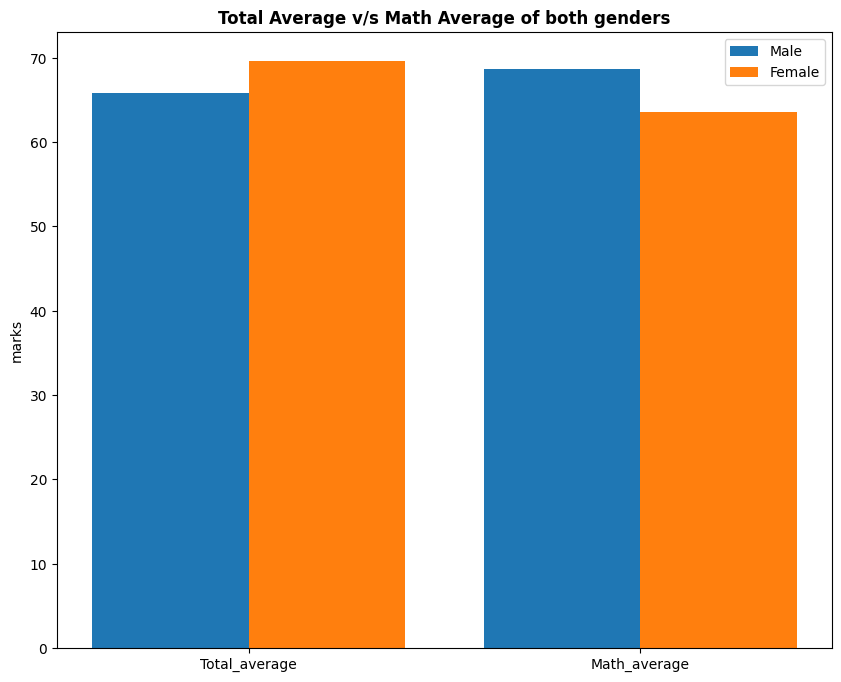

In [30]:
plt.figure(figsize=(10,8))
X = ['Total_average','Math_average']

female_scores = [gender_group["Average_score"][1],gender_group['math_score'][1]]
male_scores = [gender_group['Average_score'][0],gender_group['math_score'][0]]

X_axis=np.arange(len(X))

plt.bar(X_axis-0.2,male_scores,0.4,label='Male')
plt.bar(X_axis+0.2,female_scores,0.4,label='Female')
plt.xticks(X_axis,X)
plt.ylabel("marks")
plt.title("Total Average v/s Math Average of both genders",fontweight='bold')
plt.legend()
plt.show()

*Insights*
* Female Students have higher Overall score than Male students 
* while Male Students have high marks in maths than Female Students

*RACE/EHNICITY COLUMN*
* How is Group wise distribution ?
* Is Race/Ehnicity has any impact on student's performance ?

# UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

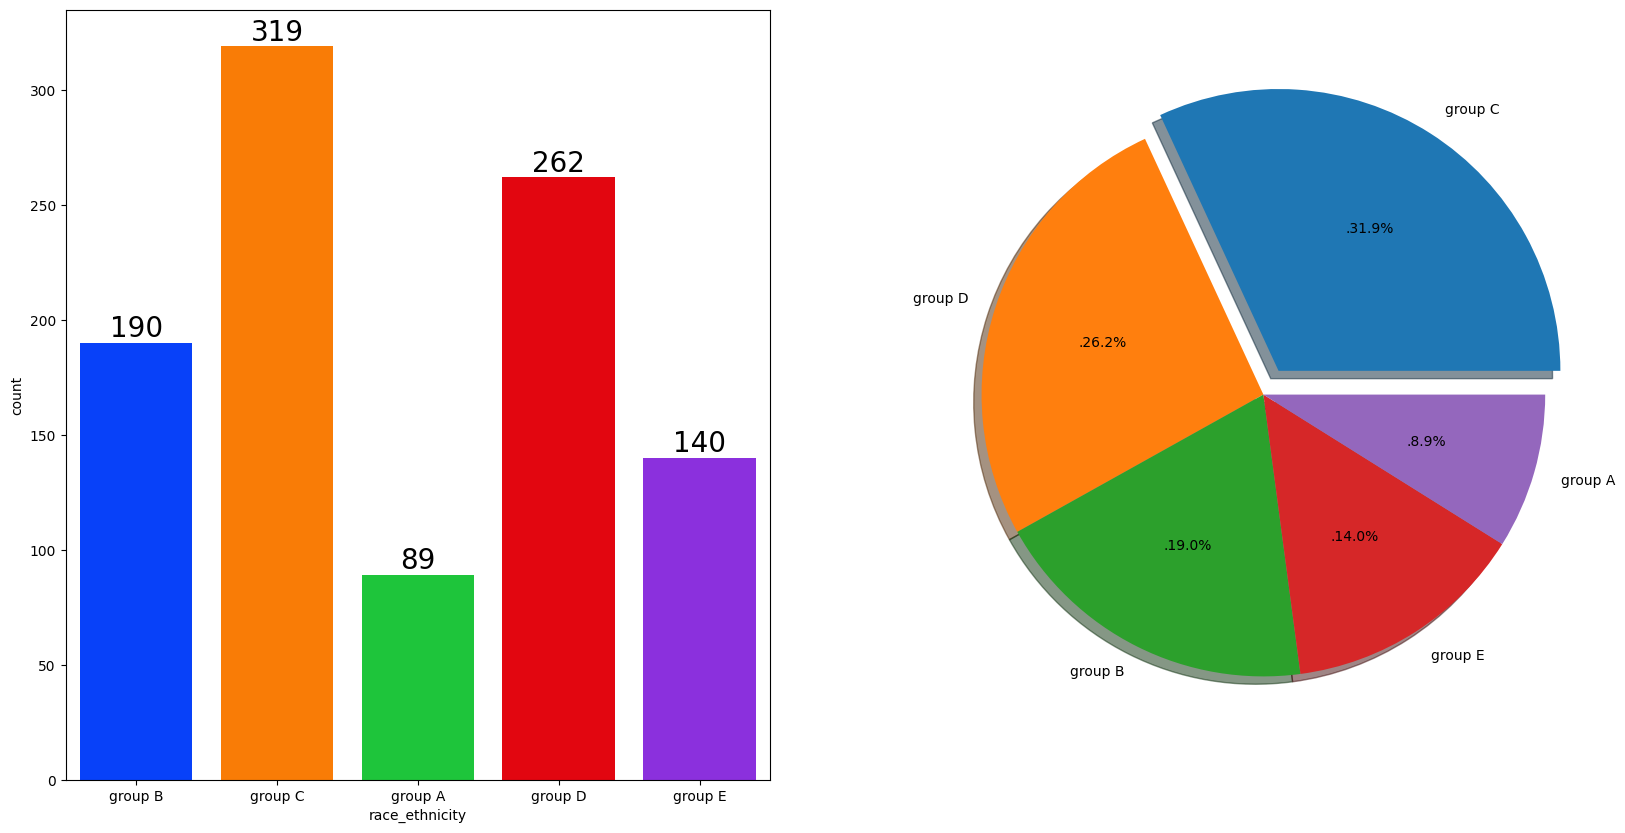

In [31]:
f,ax = plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df,x=df['race_ethnicity'],palette='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
plt.pie(x=df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='.%1.1f%%',shadow='True')
plt.show()

*Insights*
* Most of students belong to group C/group D
* Group A has Least no. of students

# BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

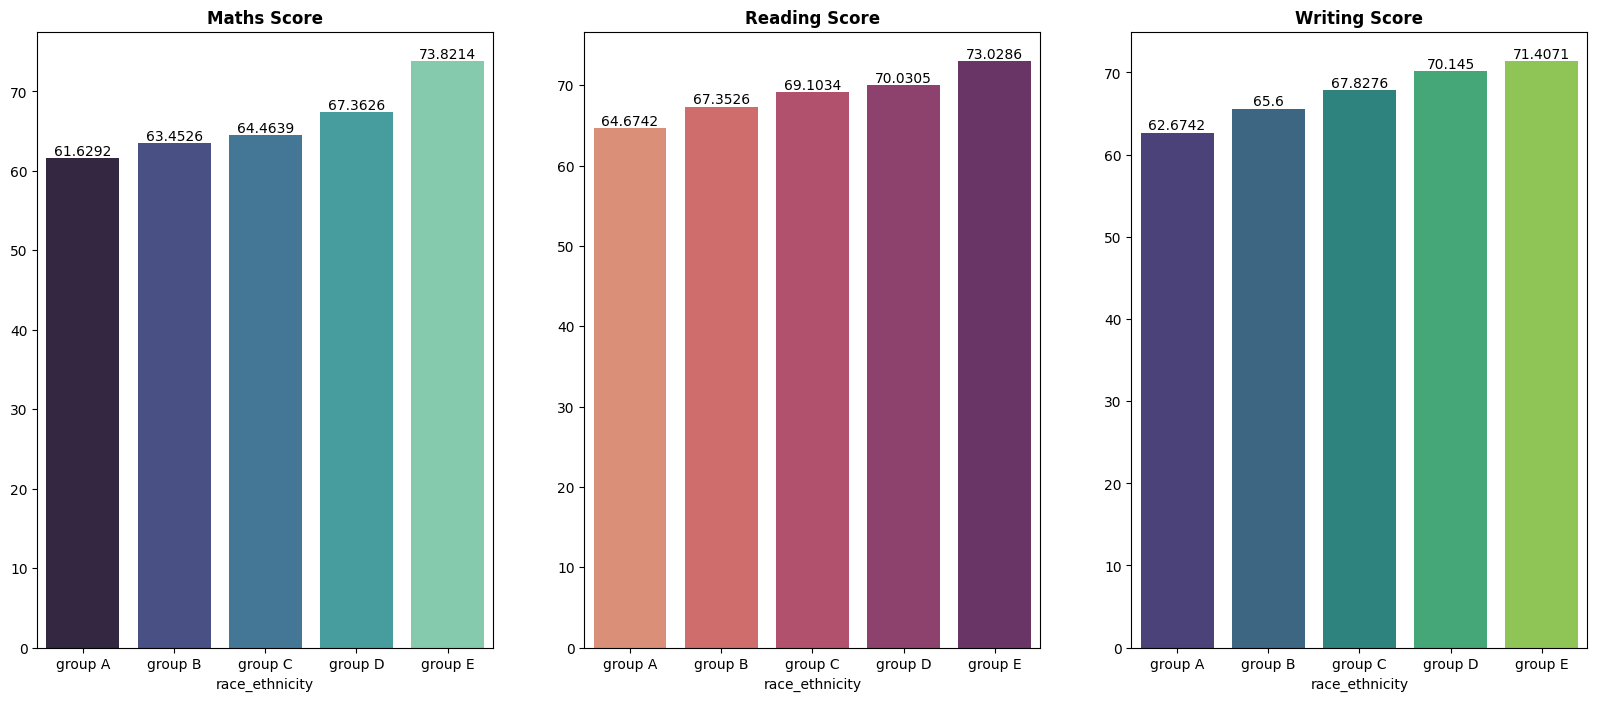

In [32]:
race_group = df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=race_group['math_score'].mean().index,y=race_group['math_score'].mean().values,ax=ax[0],palette='mako')
ax[0].set_title('Maths Score', fontweight='bold')
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=10)

sns.barplot(x=race_group['reading_score'].mean().index,y=race_group['reading_score'].mean().values,ax=ax[1],palette='flare')
ax[1].set_title('Reading Score',fontweight='bold')
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=10)
    
sns.barplot(x=race_group['writing_score'].mean().index,y=race_group['writing_score'].mean().values,ax=ax[2],palette='viridis')
ax[2].set_title('Writing Score',fontweight='bold')
for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=10)

*Insights*
* Group E Students scores highest in all three subjects 
* Group A Students scores lowest followed by Group B in all 3 subjects 


# PARENTAL LEVEL OF EDUCATION COLUMN
* What is educational background of student's parent ?
* Is parental education has any impact on student's performance ?

# UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

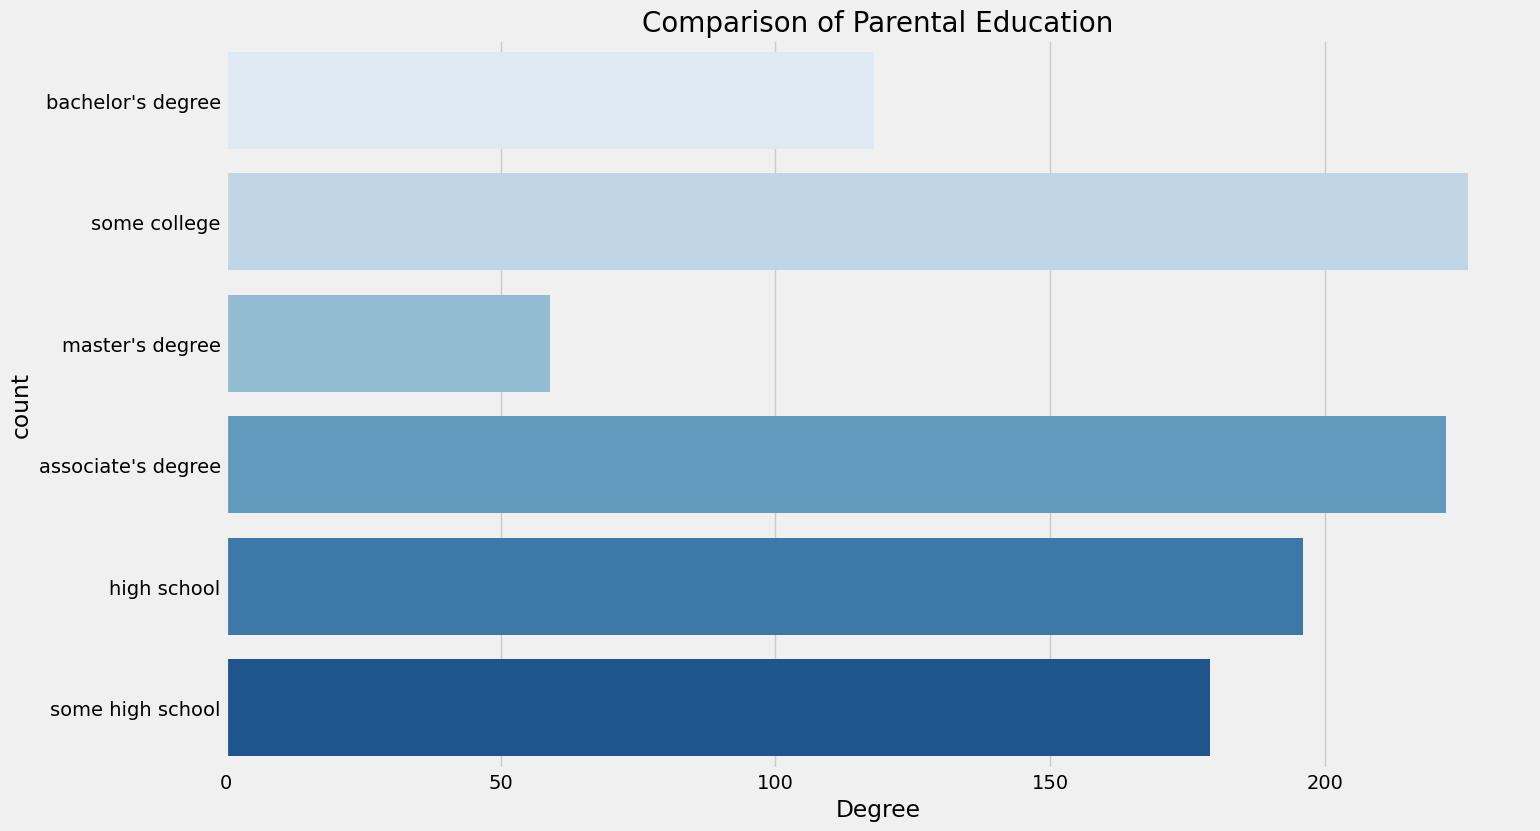

In [33]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

*Insights*
* Largest number of parents are from same college

# BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

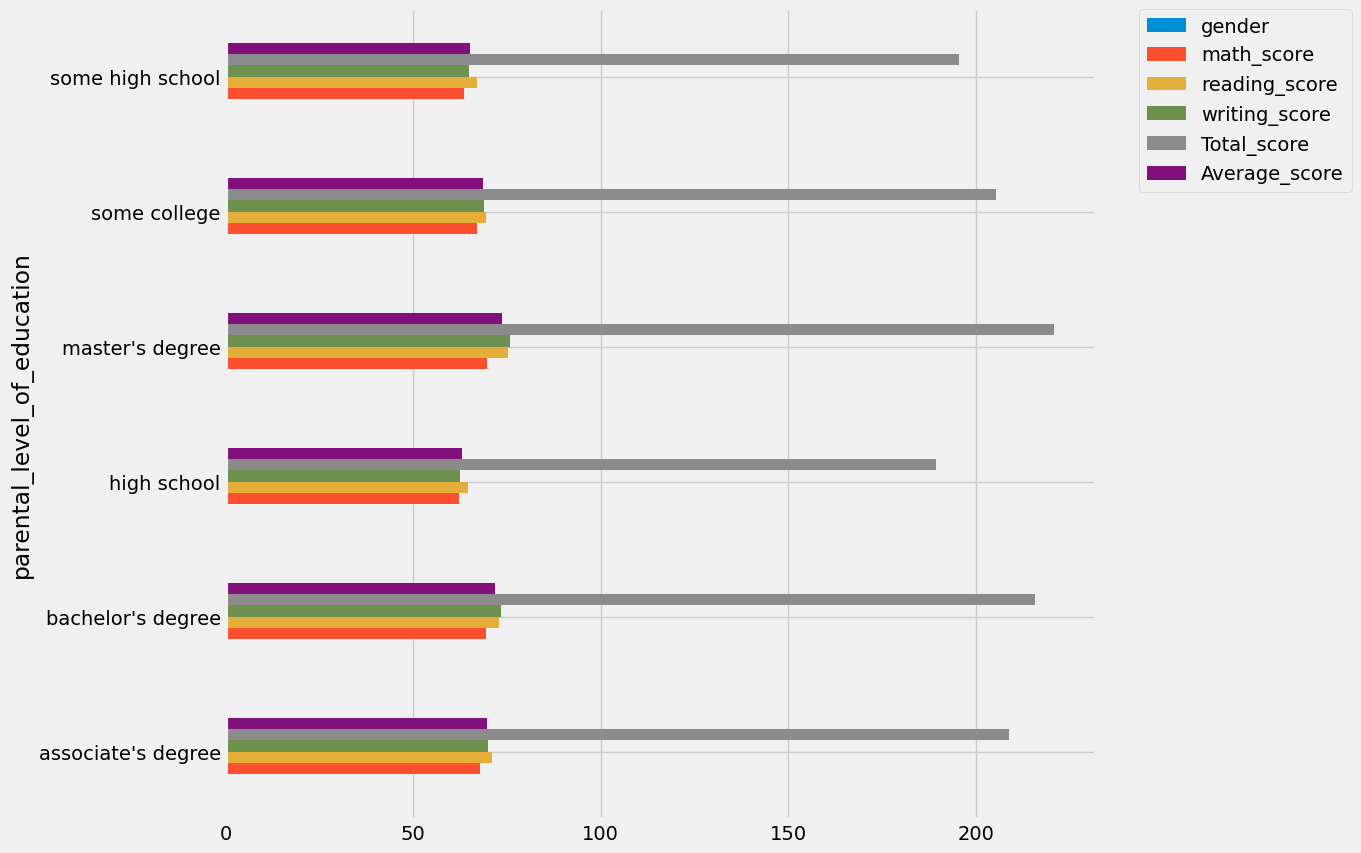

In [34]:
df.groupby('parental_level_of_education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

*Insights*
* Students whose Parents posses masters and bachelor's level of education have higher scores than others

# LUNCH COLUMN
* Which type of lunch is most common amoung students ?
* What is the effect of lunch type on test results?

*UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )*

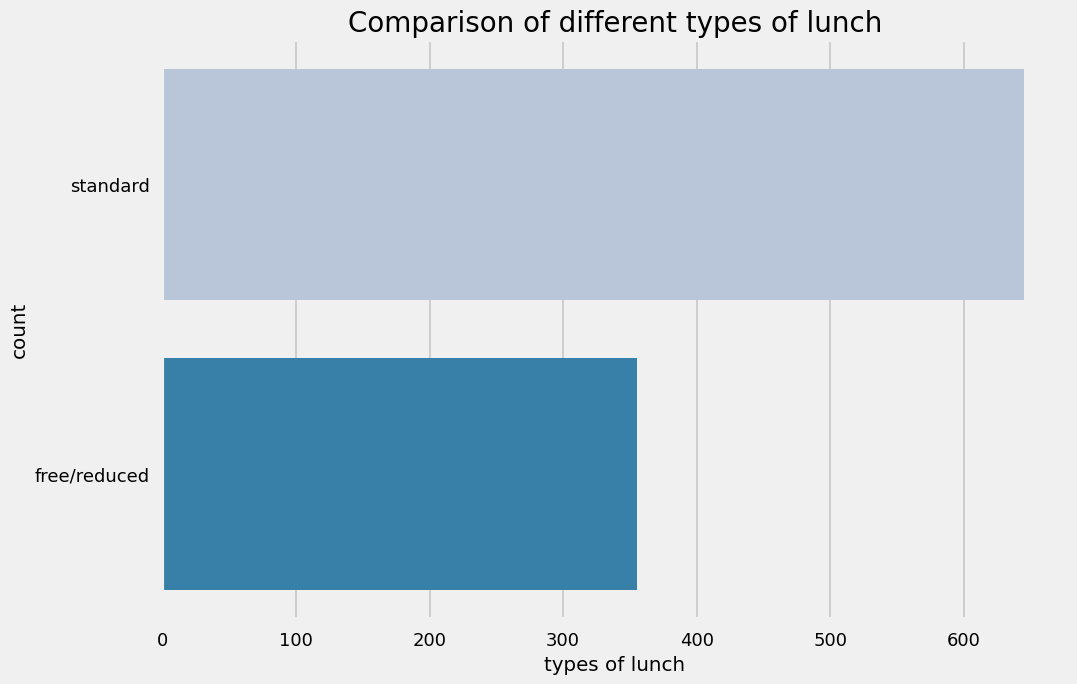

In [35]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

*Insights* 
* Students Are served Stanndard Lunch more than free lunch

*BIVARIATE ANALYSIS ( Is lunch type intake has any impact on student's performance ? )*

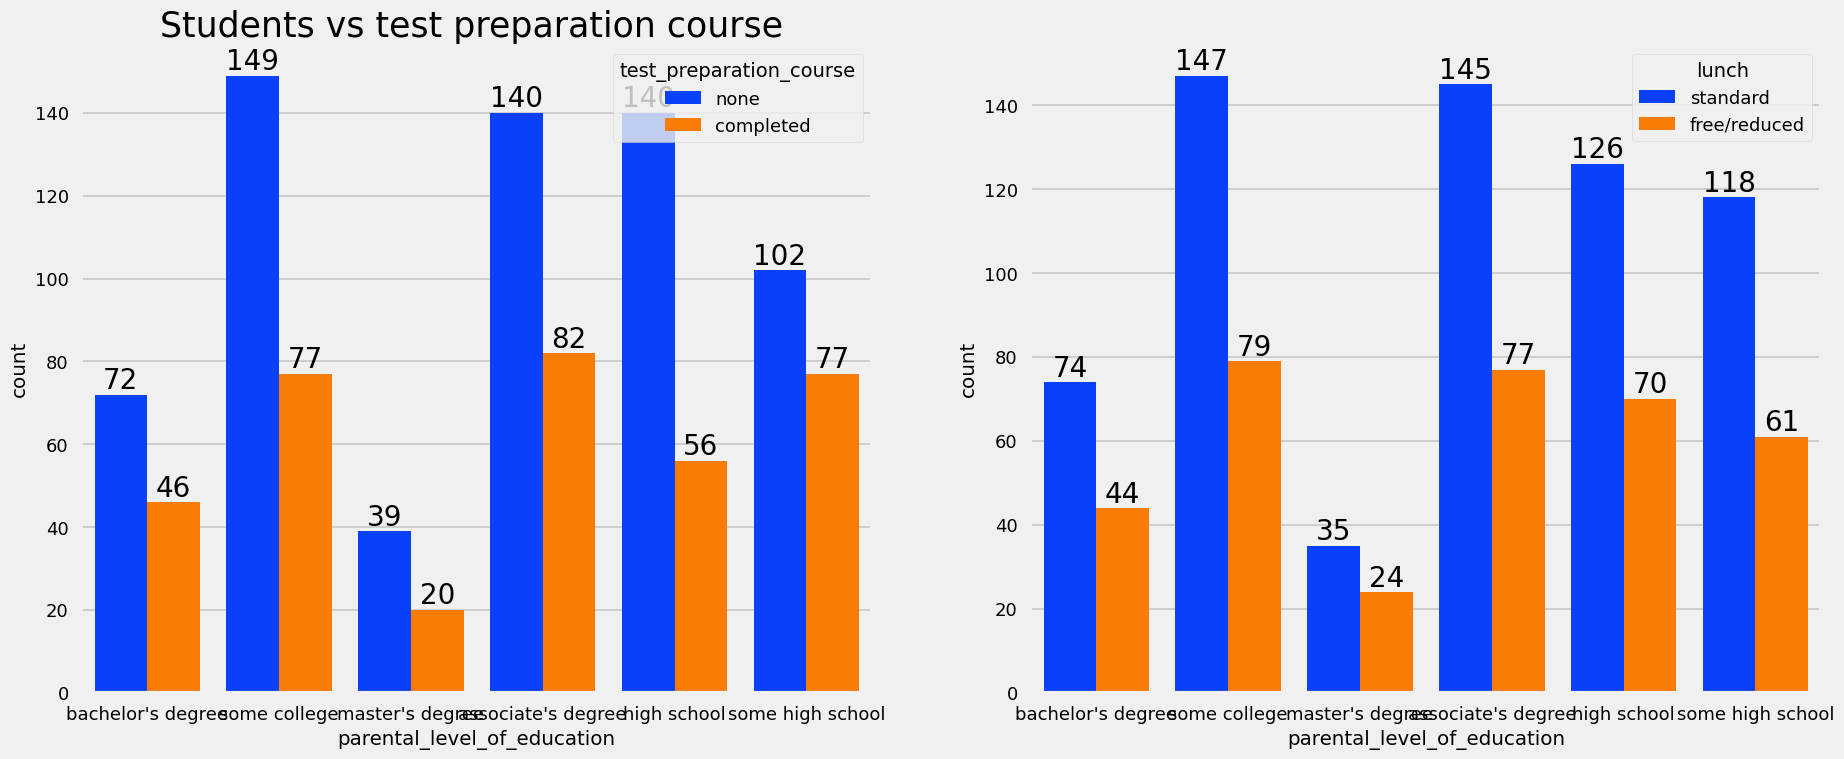

In [36]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=df['parental_level_of_education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

* Students who get standard lunch are performing better in exam


#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

In [38]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,Average_score
0,1,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,1,group C,some college,standard,completed,69,90,88,247,82.333333


<Axes: xlabel='lunch', ylabel='Average_score'>

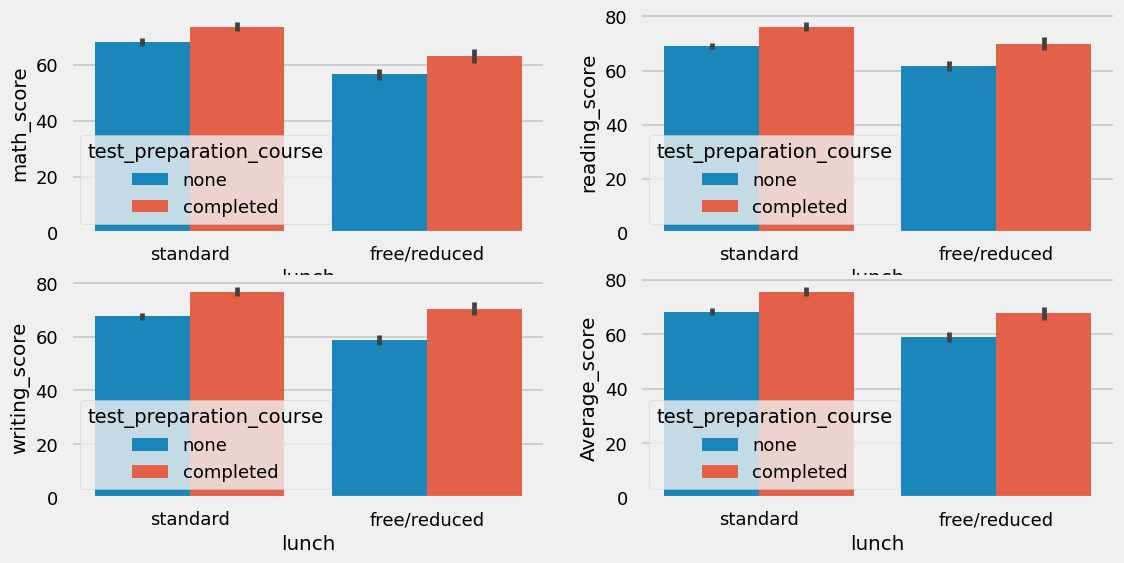

In [41]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])
plt.subplot(2,2,4)
sns.barplot (x=df['lunch'], y=df['Average_score'], hue=df['test_preparation_course'])

**Insights**
* Students who have completed their Test prep course have scored higher

# Checking Outliers 

<Axes: ylabel='Average_score'>

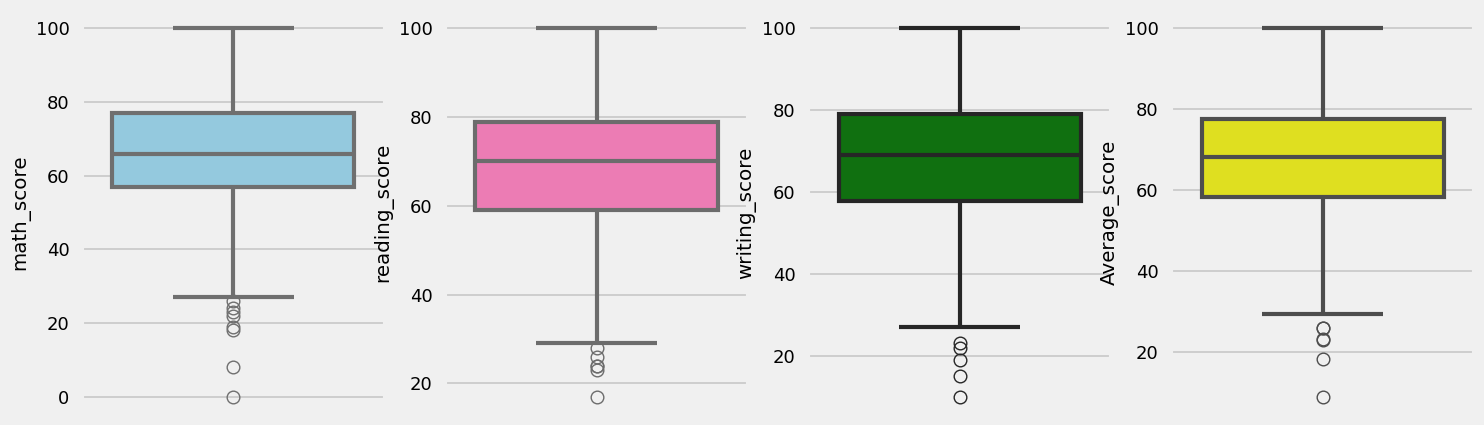

In [43]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue',linewidth=3)
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink',linewidth=3)
plt.subplot(143)
sns.boxplot(df['writing_score'],color='green',linewidth=3)
plt.subplot(144)
sns.boxplot(df['Average_score'],color='yellow',linewidth=3)


# Multivariate Analysis Using Pairplot

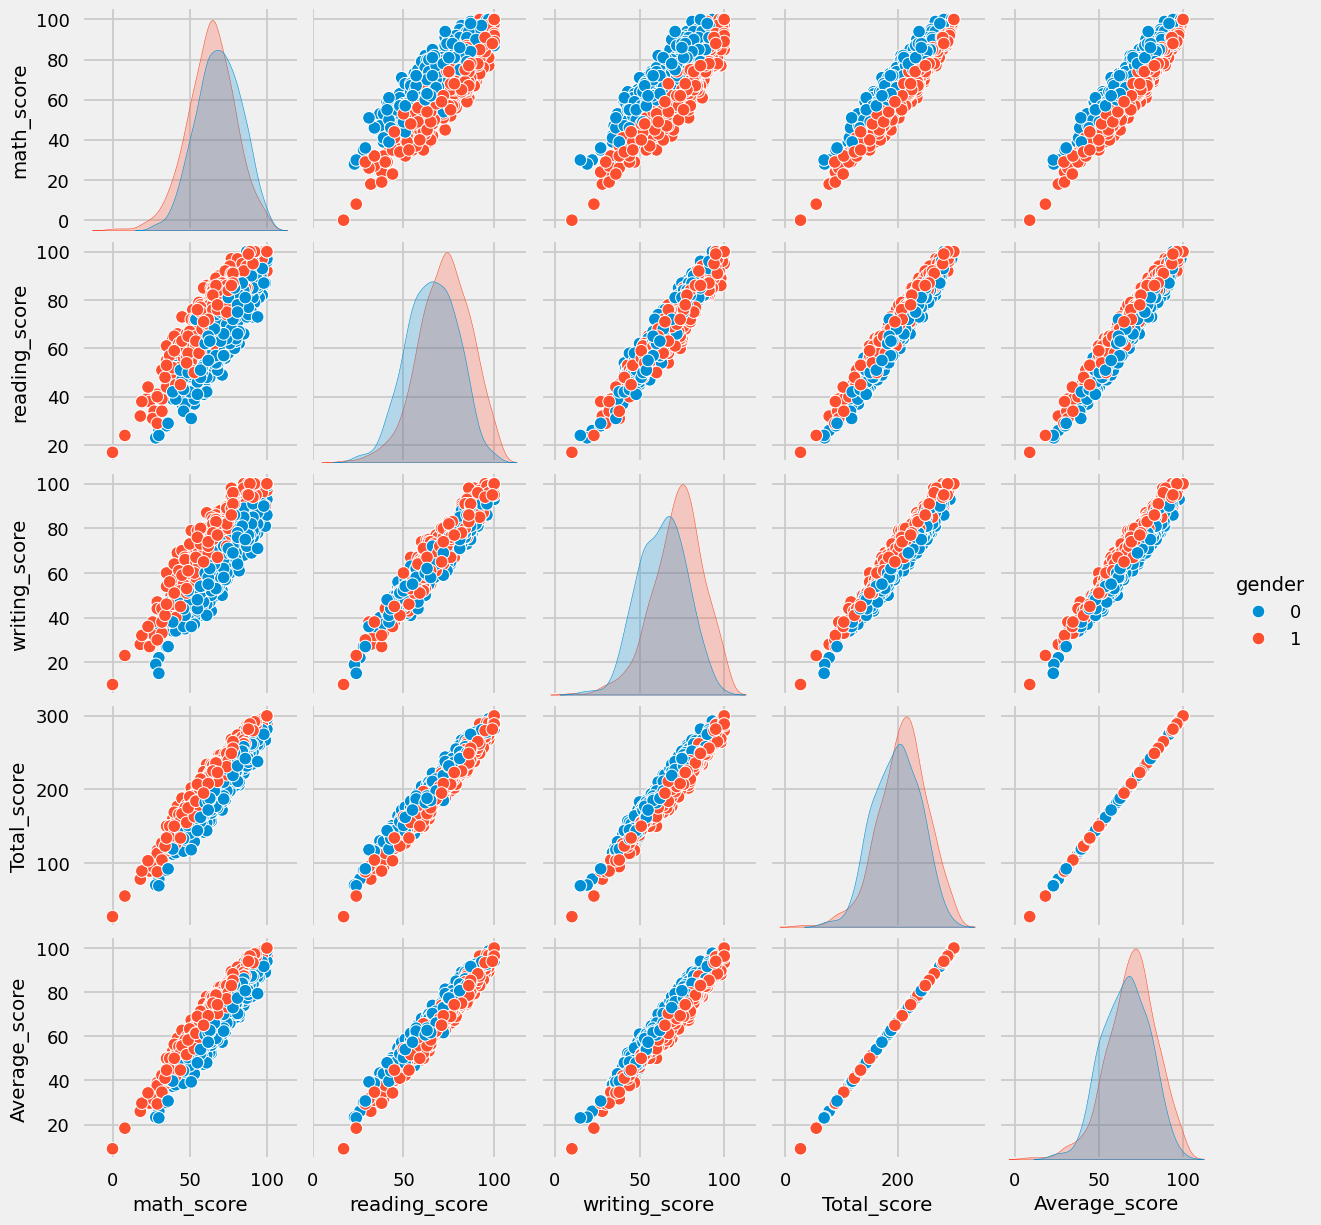

In [45]:
sns.pairplot(df,hue='gender')
plt.show()

**Insights**
* From above plot it is clear that all scores increase linearly with each other

###  Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.